In [ ]:
import pandas as pd

orders = pd.read_csv("/content/olist_orders_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")

df = orders.merge(payments, on='order_id')
df = df.merge(customers, on='customer_id')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(df.head())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [ ]:
# Monthly revenue
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df.groupby('month')['payment_value'].sum()

print(monthly_revenue.head())

month
2016-09       252.24
2016-10     59090.48
2016-12        19.62
2017-01    138488.04
2017-02    291908.01
Freq: M, Name: payment_value, dtype: float64


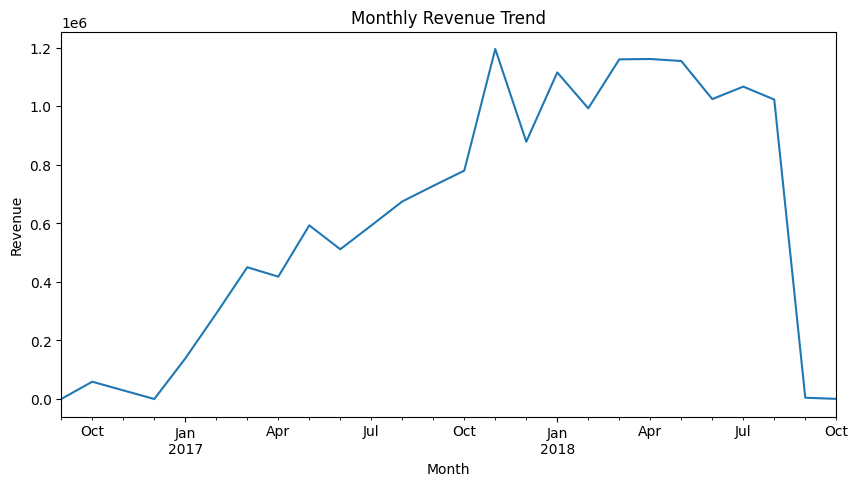

In [ ]:
import matplotlib.pyplot as plt

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [ ]:
import datetime as dt

last_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].max()

current_date = df['order_purchase_timestamp'].max()

recency = (current_date - last_purchase).dt.days

churn = recency.apply(lambda x: 1 if x > 90 else 0)

churn_df = pd.DataFrame({
    'recency': recency,
    'churn': churn
})

print(churn_df.head())

                                  recency  churn
customer_unique_id                              
0000366f3b9a7992bf8c76cfdf3221e2      160      1
0000b849f77a49e4a4ce2b2a4ca5be3f      163      1
0000f46a3911fa3c0805444483337064      585      1
0000f6ccb0745a6a4b88665a16c9f078      369      1
0004aac84e0df4da2b147fca70cf8255      336      1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = churn_df[['recency']]
y = churn_df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 1.0


In [ ]:
# Revenue per customer
customer_revenue = df.groupby('customer_unique_id')['payment_value'].sum()

# Top customers
top_customers = customer_revenue.sort_values(ascending=False).head(10)

print(top_customers)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


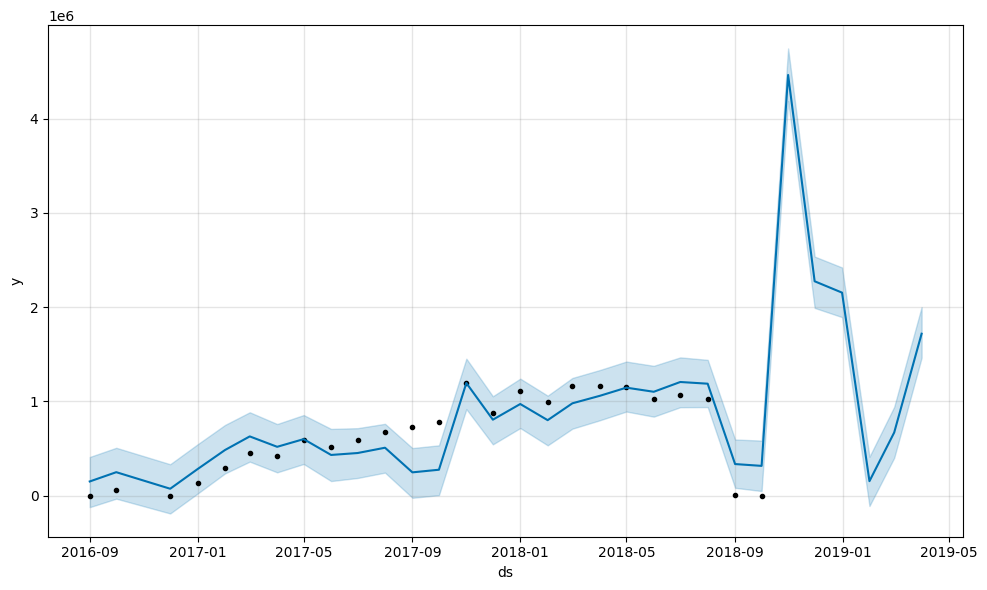

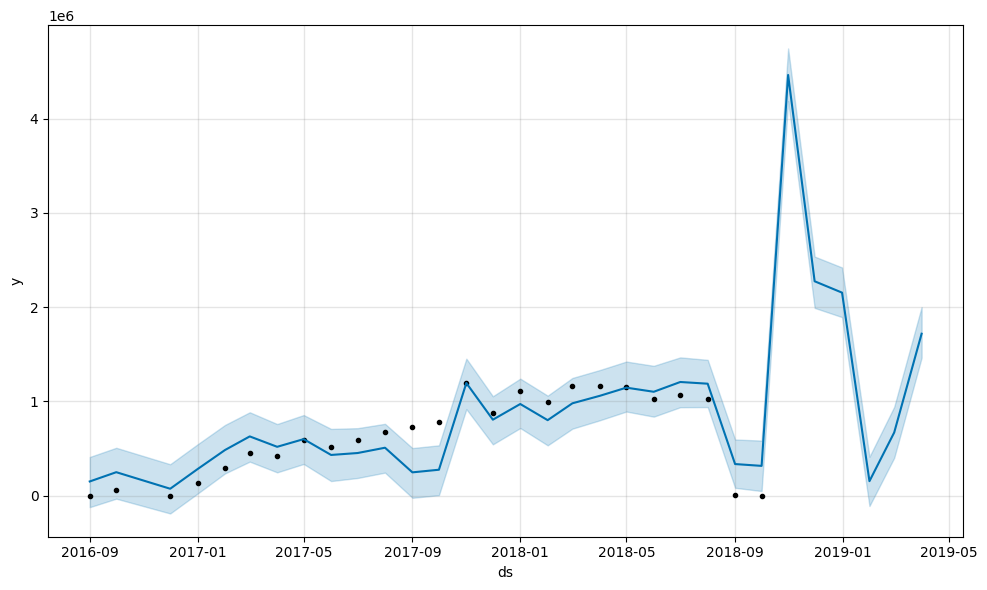

In [ ]:
from prophet import Prophet

# Prepare data
forecast_df = monthly_revenue.reset_index()
forecast_df.columns = ['ds', 'y']
forecast_df['ds'] = forecast_df['ds'].astype(str)

# Model
model = Prophet()
model.fit(forecast_df)

future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

model.plot(forecast)

In [ ]:
total_revenue = df['payment_value'].sum()
avg_order_value = df['payment_value'].mean()
churn_rate = churn.mean()

print(total_revenue, avg_order_value, churn_rate)

16008872.12 154.10038041699553 0.8994328529059784
